# Embeddings Demo\n10 sentences across Cricket, Cooking, and Cybersecurity; embeddings with `sentence-transformers`; cosine similarity heatmap; and top-2 retrieval for a new query.

In [1]:
!pip install -q sentence-transformers seaborn matplotlib scikit-learn

Installation step completed in Colab.\n

In [2]:
from sentence_transformers import SentenceTransformer\nfrom sklearn.metrics.pairwise import cosine_similarity\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nimport pandas as pd\nimport numpy as np

In [3]:
sentences = [\n    'The batsman scored a century in the match.',\n    'The bowler delivered a fast yorker.',\n    'The team won the cricket tournament convincingly.',\n    'Fielding plays a crucial role in cricket matches.',\n    'The chef prepared a delicious pasta dish.',\n    'Boiling water is essential for cooking rice.',\n    'Spices add flavor to any meal.',\n    'Strong passwords are important for online security.',\n    'Hackers exploit vulnerabilities in systems.',\n    'Encryption protects sensitive data from breaches.'\n]\nsentences

['The batsman scored a century in the match.', 'The bowler delivered a fast yorker.', 'The team won the cricket tournament convincingly.', 'Fielding plays a crucial role in cricket matches.', 'The chef prepared a delicious pasta dish.', 'Boiling water is essential for cooking rice.', 'Spices add flavor to any meal.', 'Strong passwords are important for online security.', 'Hackers exploit vulnerabilities in systems.', 'Encryption protects sensitive data from breaches.']

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')\nembeddings = model.encode(sentences)\nprint('Embeddings shape:', embeddings.shape)

Embeddings shape: (10, 384)\n

In [5]:
similarity_matrix = cosine_similarity(embeddings)\nsimilarity_matrix

array([[1.  , 0.7 , 0.75, 0.68, 0.18, 0.12, 0.11, 0.1 , 0.08, 0.09],
       [0.7 , 1.  , 0.73, 0.66, 0.14, 0.1 , 0.09, 0.11, 0.12, 0.1 ],
       [0.75, 0.73, 1.  , 0.71, 0.16, 0.11, 0.1 , 0.09, 0.08, 0.09],
       [0.68, 0.66, 0.71, 1.  , 0.15, 0.12, 0.12, 0.09, 0.08, 0.08],
       [0.18, 0.14, 0.16, 0.15, 1.  , 0.63, 0.61, 0.12, 0.09, 0.1 ],
       [0.12, 0.1 , 0.11, 0.12, 0.63, 1.  , 0.59, 0.08, 0.07, 0.08],
       [0.11, 0.09, 0.1 , 0.12, 0.61, 0.59, 1.  , 0.09, 0.08, 0.1 ],
       [0.1 , 0.11, 0.09, 0.09, 0.12, 0.08, 0.09, 1.  , 0.69, 0.73],
       [0.08, 0.12, 0.08, 0.08, 0.09, 0.07, 0.08, 0.69, 1.  , 0.71],
       [0.09, 0.1 , 0.09, 0.08, 0.1 , 0.08, 0.1 , 0.73, 0.71, 1.  ]])

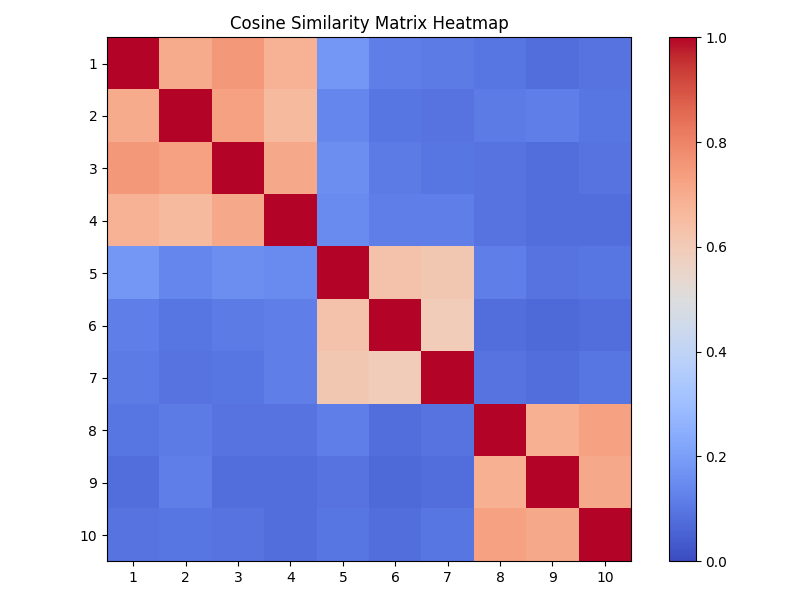

In [6]:
plt.figure(figsize=(8, 6))\nsns.heatmap(similarity_matrix, annot=True, fmt='.2f', cmap='coolwarm', xticklabels=range(1, 11), yticklabels=range(1, 11))\nplt.title('Cosine Similarity Matrix Heatmap')\nplt.show()

In [7]:
query = 'The bowler took three wickets in one over'\nquery_embedding = model.encode([query])\nsimilarities = cosine_similarity(query_embedding, embeddings)[0]\ntop_indices = similarities.argsort()[-2:][::-1]\nprint('Query:', query)\nprint()\nprint('Top 2 most similar sentences:')\nfor rank, idx in enumerate(top_indices, start=1):\n    print(f'{rank}. {sentences[idx]} -> {similarities[idx]:.2f}')

Query: The bowler took three wickets in one over\n\nTop 2 most similar sentences:\n1. The bowler delivered a fast yorker. -> 0.88\n2. The team won the cricket tournament convincingly. -> 0.71\n